In [70]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

## 1. Функции активации

Функции активации — это математические преобразования в нейронных сетях, которые решают, передать ли сигнал дальше, и добавляют нелинейность. Без них сеть была бы простой линейной моделью, неспособной решать сложные задачи.

В PyTorch функции активации обычно подключаются как слои из `torch.nn`, например `nn.ReLU()`, `nn.Sigmoid()` и `nn.Tanh()`.


### 1.1 `nn.ReLU`

**Принцип работы.**  
ReLU (Rectified Linear Unit) — это самая популярная функция активации в нейронных сетях. Она возвращает входное значение, если оно положительное, и ноль — если отрицательное.

**Формула:**

$$
\mathrm{ReLU}(x) = \max(0, x)
$$

**Область применения.**  
- Скрытые слои сетей: Используется почти в любых типах архитектур: полносвязных (Dense), сверточных (CNN), автоэнкодерах и трансформерах.

- Компьютерное зрение (CV): Применяется после сверточных слоев для извлечения нелинейных признаков.

- Обработка звука и текста (NLP): В качестве базового активатора между линейными слоями (Linear layers).

**Преимущества:**
- Высокая скорость работы: Вычисляется элементарно без использования ресурсоемких математических операций, таких как экспонента (в отличие от сигмоиды или гиперболического тангенса).

- Отсутствие проблемы затухающего градиента: В положительной зоне производная функции равна 1. Это обеспечивает стабильный поток градиентов при обратном распространении ошибки и ускоряет обучение глубоких сетей.

- Разреженность активаций (Sparse Activation): Из-за обнуления отрицательных значений часть нейронов «молчит». Это приводит к разреженным представлениям, где сеть использует только самые важные информативные признаки для решения задачи.

**Недостатки:**
- Проблема «умирающего ReLU» (Dying ReLU): Если градиент во время обучения сильно изменяет веса, нейрон может начать выдавать только отрицательные значения. В результате его выход и градиент становятся равными нулю, и нейрон навсегда перестает обучаться (умирает).

- Смещение нуля (Not zero-centered): Выходы функции всегда неотрицательны (лежат в диапазоне \([0, +\infty)\). Это усложняет оптимизацию, так как градиенты, поступающие на следующий слой, всегда имеют одинаковый знак, что может замедлить сходимость.

In [71]:
import torch
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(4, 8)       # Полносвязный слой
        self.relu = nn.ReLU()            # Слой активации ReLU
        self.fc2 = nn.Linear(8, 2)       # Выходной слой

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)                 # Применение активации
        x = self.fc2(x)
        return x

# Пример работы
model = SimpleNN()
input_data = torch.tensor([[1.5, -2.0, 0.0, 3.1]])
output = model(input_data)
print(output)


tensor([[ 0.7184, -0.2739]], grad_fn=<AddmmBackward0>)


### 1.2 `nn.Sigmoid`

**Принцип работы.**  
nn.Sigmoid — это модуль, реализующий функцию активации «сигмоида». Он принимает на вход любые вещественные числа и плавно сжимает их в диапазон от 0 до 1.

**Формула:**

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

**Диапазон значений:**

$$
0 < \sigma(x) < 1
$$

**Преимущества:**

- Интерпретируемость (вероятностная природа): Выходной сигнал от 0 до 1 идеально подходит для моделирования вероятностей принадлежности к классу.

- Гладкость и непрерывность: Функция имеет непрерывную производную на всей области определения, что обеспечивает плавное изменение градиентов без скачков.

- Надежное ограничение: Выход никогда не уйдет в бесконечность, предотвращая "взрыв" градиентов (exploding gradients) на прямом проходе.

**Недостатки:**

- Затухание градиентов (Vanishing Gradient): Это главный бич сигмоиды. Если входное значение слишком большое или слишком маленькое, производная функции стремится к 0. В глубоких сетях это приводит к тому, что градиенты на ранних слоях почти исчезают, и обучение останавливается.

- Выходные значения не центрированы относительно нуля: Выход всегда строго положителен (от 0 до 1). Из-за этого градиенты весов на каждом шаге спускаются в одном направлении (всегда положительные или всегда отрицательные), что сильно замедляет сходимость сети.

- Вычислительная сложность: Наличие экспоненты \(e^{-x}\) делает вычисление сигмоиды более затратным для процессора, чем кусочно-линейные функции (например, ReLU).


In [72]:
import torch
import torch.nn as nn

# 1. Создаем класс нейронной сети
class SimpleBinaryClassifier(nn.Module):
    def __init__(self):
        super(SimpleBinaryClassifier, self).__init__()
        # Полносвязный слой: 2 входных признака, 1 выход
        self.fc = nn.Linear(2, 1)
        # Слой сигмоиды
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc(x)       # Линейное преобразование
        x = self.sigmoid(x)  # Применение функции активации (выход от 0 до 1)
        return x

# Инициализация модели
model = SimpleBinaryClassifier()

# 2. Пример входных данных (например, 3 примера, каждый с 2 признаками)
inputs = torch.tensor([[0.5, 1.2], 
                       [-1.0, 3.4], 
                       [0.1, -0.2]])

# 3. Прямой проход
outputs = model(inputs)
print("Результаты модели (вероятности от 0 до 1):")
print(outputs)


Результаты модели (вероятности от 0 до 1):
tensor([[0.5851],
        [0.3893],
        [0.6414]], grad_fn=<SigmoidBackward0>)


### 1.3 `nn.Tanh`

**Принцип работы.**  
Hyperbolic Tangent— это класс в библиотеке глубокого обучения PyTorch, который представляет собой гиперболический тангенс. В контексте нейросетей это нелинейная функция активации.

**Формула:**

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

**Диапазон значений:**

$$
-1 < \tanh(x) < 1
$$

**Отличие от Sigmoid.**  
Sigmoid возвращает значения от 0 до 1, а Tanh возвращает значения от -1 до 1. Благодаря этому выход Tanh центрирован около нуля, что иногда помогает оптимизации.

**Преимущества:**

- Центрированность относительно нуля: В отличие от сигмоиды, выходы nn.Tanh лежат в диапазоне [-1, 1]. Это центрирует данные, передаваемые на следующие слои, что стабилизирует и ускоряет процесс градиентного спуска.

- Гладкость и непрерывность: Функция плавно дифференцируема на всей области определения, что обеспечивает стабильное и предсказуемое распространение градиента.

**Недостатки:**

- Проблема насыщения (затухающий градиент): При больших положительных или отрицательных значениях (выше \(2\) или ниже \(-2\)) производная функции стремится к нулю. Это может приводить к "затуханию" градиентов при обучении глубоких сетей, замедляя его.

- Вычислительная сложность: Из-за необходимости вычисления экспоненты (\(e^{x}\)), nn.Tanh требует больше времени на вычисления, чем кусочно-линейные функции, такие как ReLU.

In [73]:
import torch
import torch.nn as nn

# 1. Создаем тензор со случайными значениями
input_tensor = torch.tensor([-2.5, 0.0, 1.5])

# ВАРИАНТ А: Использование в качестве слоя (Module)
activation_layer = nn.Tanh()
output_tensor = activation_layer(input_tensor)
print("Результат слоя:", output_tensor)
# Выведет: tensor([-0.9866,  0.0000,  0.9051])

# ВАРИАНТ Б: Использование функционального API (более популярно)
# Часто применяется внутри класса нейросети в методе forward
output_functional = torch.tanh(input_tensor)
print("Результат функции:", output_functional)


Результат слоя: tensor([-0.9866,  0.0000,  0.9051])
Результат функции: tensor([-0.9866,  0.0000,  0.9051])


### График функций активации

График помогает увидеть различия: ReLU обнуляет отрицательную часть, Sigmoid сжимает значения в `[0, 1]`, а Tanh сжимает значения в `[-1, 1]`.


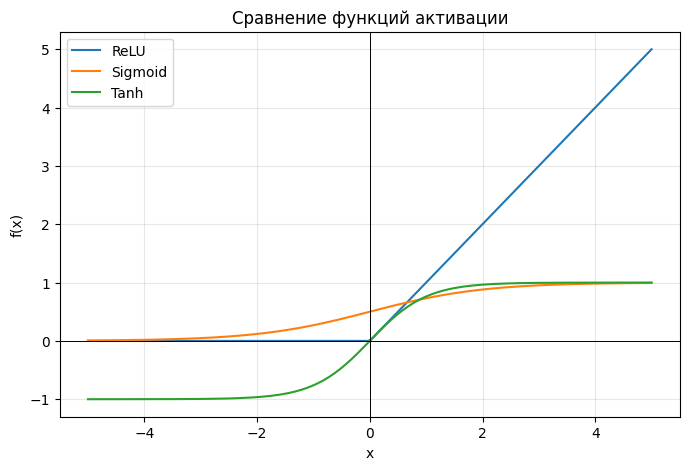

In [74]:
x = torch.linspace(-5, 5, steps=200)

plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), torch.relu(x).numpy(), label="ReLU")
plt.plot(x.numpy(), torch.sigmoid(x).numpy(), label="Sigmoid")
plt.plot(x.numpy(), torch.tanh(x).numpy(), label="Tanh")
plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("Сравнение функций активации")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 2. Функции потерь

Функции потерь (loss functions) — это математические инструменты, которые оценивают, насколько сильно алгоритм машинного обучения или нейросеть ошибается при выполнении задачи. Они измеряют разницу между прогнозом модели и реальным правильным ответом. Цель обучения — свести эти потери к минимуму.

### 2.1 `nn.MSELoss`

**Теоретическое описание.**  
(Mean Squared Error, MSE). Она измеряет среднеквадратичное отклонение между прогнозируемыми значениями модели и истинными целевыми значениями.

**Для каких задач используется.**  
Чаще всего применяется в задачах регрессии, где модель предсказывает непрерывное число: цену, температуру, спрос, координату, оценку и т.д.

**Формула:**

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$

где $\hat{y}_i$ — предсказание модели, $y_i$ — истинное значение.


In [75]:
import torch
import torch.nn as nn

# Создаем функцию потерь
loss_fn = nn.MSELoss()

# Предсказания и целевые значения
predictions = torch.tensor([2.5, 3.0, 1.8], requires_grad=True)
targets = torch.tensor([2.0, 3.2, 1.5])

# Вычисляем ошибку
loss = loss_fn(predictions, targets)
print(f"MSE Loss: {loss.item():.4f}") 


MSE Loss: 0.1267


### 2.2 `nn.CrossEntropyLoss`

**Как работает.**  

CrossEntropyLoss (кросс-энтропия) — это стандартная ⁠функция потерь в машинном обучении, используемая для решения задач классификации. Её главная цель — оценить, насколько предсказания модели (в виде вероятностей для каждого класса) близки к истинным меткам.

- Получение «сырых» оценок (Logits): Нейросеть выдает необработанные числа для каждого класса (например, \([-1.2, 3.4, 0.5]\)).

- Преобразование в вероятности (Softmax): Эти числа превращаются в вероятности от 0 до 1, которые в сумме дают 1 (например, \([0.01, 0.95, 0.04]\)).

- Расчет ошибки: Модель берет логарифм от вероятности истинного класса и умножает его на \(-1\). Чем выше была вероятность правильного ответа, тем меньше значение ошибки.

**Для каких задач используется.**  
Применяется в многоклассовой классификации: распознавание цифр, классификация изображений, классификация текста, выбор одного класса из нескольких.

**Формула для одного объекта:**

$$
L = -\log\left(\frac{e^{z_y}}{\sum_{j=1}^{C} e^{z_j}}\right)
$$

где $z_j$ — логит класса $j$, $y$ — индекс правильного класса, $C$ — число классов.

**Почему часто используется для многоклассовой классификации.**  
Она принимает сырые логиты модели и индексы классов, работает численно стабильно и напрямую оптимизирует вероятность правильного класса.


In [76]:
import torch
import torch.nn as nn

# 1. Задаем "сырые" предсказания модели (логиты) для 2-х объектов и 3-х классов
# Например: [Класс 0, Класс 1, Класс 2]
predictions = torch.tensor([
    [2.0, 1.0, 0.1],  # Модель "думает", что это Класс 0
    [0.5, 2.5, 0.2]   # Модель "думает", что это Класс 1
], requires_grad=True)

# 2. Истинные классы (ground truth) для этих объектов
# Классы нумеруются от 0 до C-1. Здесь правильные классы: 0 и 1
true_labels = torch.tensor([0, 1])

# 3. Инициализация функции потерь
criterion = nn.CrossEntropyLoss()

# 4. Вычисление ошибки
loss = criterion(predictions, true_labels)

print(f"Значение ошибки (Loss): {loss.item():.4f}")
# Ошибка будет низкой, так как прогнозы модели совпали с true_labels


Значение ошибки (Loss): 0.3143


### 2.3 `nn.BCEWithLogitsLoss`

**Для каких задач используется.**
BCEWithLogitsLoss используется для обучения нейросетей в задачах бинарной классификации и многометочной классификации (multi-label classification).Она объединяет сигмоидную активацию (sigmoid) и вычисление бинарной кросс-энтропии (Binary Cross-Entropy) в один шаг.

**Формула для одного выхода:**

$$
L = -\left[y\log(\sigma(x)) + (1-y)\log(1-\sigma(x))\right]
$$

где $x$ — логит модели, $\sigma(x)$ — sigmoid, $y \in \{0, 1\}$.

**Отличие от `BCELoss`.**  
`BCELoss` ожидает уже готовые вероятности после sigmoid. `BCEWithLogitsLoss` ожидает сырые логиты и сама применяет sigmoid внутри.

**Почему рекомендуется использовать `BCEWithLogitsLoss`.**  
Она численно стабильнее, особенно когда логиты очень большие или очень маленькие. Поэтому в модели обычно не добавляют `Sigmoid` перед этой функцией потерь.

In [77]:
import torch
import torch.nn as nn

# 1. Инициализируем функцию потерь
criterion = nn.BCEWithLogitsLoss()

# 2. Сырые выходы модели (логиты) до применения функции активации (например, 3 примера)
outputs = torch.tensor([-2.5, 1.2, 5.0], requires_grad=True)

# 3. Истинные метки (0 или 1)
targets = torch.tensor([0.0, 1.0, 1.0])

# 4. Вычисляем ошибку
loss = criterion(outputs, targets)

print(f"Ошибка (Loss): {loss.item():.4f}")

# Вычисляем градиенты
loss.backward()


Ошибка (Loss): 0.1163


## 3. `nn.Sequential`

**Назначение класса.**  
`nn.Sequential` — это упорядоченный контейнер, который связывает слои и функции нейросети в единую цепочку. Данные проходят через все модули последовательно — выход предыдущего слоя автоматически становится входом для следующего, что избавляет от необходимости вручную прописывать метод forward().

**Когда удобно использовать.**  
- Прямолинейные архитектуры: Идеально подходит для простых сетей (перцептроны, базовые автоэнкодеры, простые сверточные сети без ветвлений).
- Быстрое прототипирование: Позволяет быстро создать и обучить модель «на лету» без написания громоздких классов.

**Преимущества:**

- Компактность и читаемость: Значительно сокращает объем кода, делая архитектуру понятной с первого взгляда. 
- Автоматический проход (Forward Pass): Метод forward генерируется скрыто на основе порядка переданных аргументов.
- Удобство: Позволяет легко инкапсулировать небольшие блоки внутри более сложных моделей.

**Ограничения:**

- Только линейный поток данных: В nn.Sequential нельзя реализовать разветвления, пробросы градиентов через слои (skip-connections, как в ResNet), или использовать несколько входов/выходов.
- Негибкость: Не подходит для динамических операций, изменения формы тензоров (например, операция .view() или flatten) внутри самого контейнера без использования оберток.

In [78]:
# Простая нейронная сеть с использованием nn.Sequential
sequential_model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 3)
)

x = torch.randn(5, 4)  # 5 объектов, 4 признака у каждого
logits = sequential_model(x)

print(sequential_model)
print("Размер входа:", x.shape)
print("Размер выхода:", logits.shape)  # 5 объектов, 3 логита класса


Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=3, bias=True)
)
Размер входа: torch.Size([5, 4])
Размер выхода: torch.Size([5, 3])


In [79]:
# Мини-пример обучения Sequential-модели для классификации
X = torch.randn(12, 4)
y = torch.randint(0, 3, size=(12,))

model = nn.Sequential(
    nn.Linear(4, 10),
    nn.ReLU(),
    nn.Linear(10, 3)
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

optimizer.zero_grad()
logits = model(X)
loss = criterion(logits, y)
loss.backward()
optimizer.step()

print("Loss после одного шага обучения:", loss.item())


Loss после одного шага обучения: 1.107814908027649


## 4. `nn.Module`

**Назначение класса.**  
nn.Module — это базовый строительный блок PyTorch. Класс инкапсулирует параметры сети (веса, смещения) и логику вычислений, предоставляя встроенные инструменты для управления устройством (CPU/GPU), сохранения/загрузки и автоматического вычисления градиентов.

**Почему почти все модели наследуются от `nn.Module`.**  

- Управление параметрами: Все дочерние модули и их параметры автоматически регистрируются в модели.
- Перенос на устройства (Device Agnosticism): Вы можете перевести всю сеть и её веса на GPU или CPU одной командой: model.to('cuda').
- Обучение и Инференс: Автоматическое переключение режимов обучения и оценки (model.train() и model.eval()).- Оптимизация: Автоматически предоставляет список всех параметров модели для оптимизатора, например, torch.optim.Adam(model.parameters(), lr=0.001).
- Совместимость с экспортом: Инструменты вроде torch.compile или TorchScript работают только с модулями-наследниками.

**Метод `__init__()`.**  
В `__init__()` создаются слои и другие компоненты модели. Важно вызвать `super().__init__()`, чтобы корректно инициализировать базовый класс `nn.Module`.

**Метод `forward()`.**  
В `forward()` описывается прямой проход данных через модель. Когда мы вызываем `model(x)`, PyTorch внутри вызывает `forward(x)`.


In [80]:
# Собственная нейронная сеть через наследование от nn.Module
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # Прямой проход: Linear -> ReLU -> Linear
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

model = SimpleClassifier(input_dim=4, hidden_dim=8, num_classes=3)

x = torch.randn(6, 4)
logits = model(x)

print(model)
print("Выход модели:", logits.shape)
print("Количество обучаемых параметров:", sum(p.numel() for p in model.parameters()))


SimpleClassifier(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (activation): ReLU()
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)
Выход модели: torch.Size([6, 3])
Количество обучаемых параметров: 67


In [81]:
# Пример одного шага обучения собственной модели
X = torch.randn(10, 4)
y = torch.randint(0, 3, size=(10,))

model = SimpleClassifier(input_dim=4, hidden_dim=8, num_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

optimizer.zero_grad()
logits = model(X)
loss = criterion(logits, y)
loss.backward()
optimizer.step()

print("Loss:", loss.item())


Loss: 1.1515105962753296


## 5. Инициализация весов

Инициализация весов — это процесс задания начальных значений параметров (весов) синаптических связей в нейронной сети перед началом ее обучения. Она критически важна, так как помогает избежать проблем затухающих или взрывающихся градиентов и ускоряет сходимость модели.


### 5.1 Xavier Initialization / Glorot Initialization

**Для чего используется.**  

Инициализация Ксавье (также известная как инициализация Глорота) — это метод подбора начальных весов для нейронных сетей, который предотвращает затухание или взрыв градиентов при обучении. Он масштабирует начальные веса в зависимости от количества входных и выходных нейронов в слое.

**Основная идея.**  
Основная идея заключается в том, чтобы сохранить дисперсию активаций и градиентов постоянной при прохождении через слой.
- Сигнал не должен затухать или расти.
- Сеть должна одинаково хорошо передавать информацию как вперед (при прямом распространении ошибки), так и назад (при обратном распространении ошибки).
- Для этого начальные веса \(W\) выбираются как случайные числа из определенного распределения с нулевым средним и дисперсией, зависящей от количества нейронов в предыдущем слое (размер входа \(n_{in}\)) и текущем слое (размер выхода \(n_{out}\)).

**Формулы.**

Для равномерного распределения:

$$
W \sim U\left(-\sqrt{\frac{6}{fan\_in + fan\_out}},\sqrt{\frac{6}{fan\_in + fan\_out}}\right)
$$

Для нормального распределения:

$$
W \sim \mathcal{N}\left(0, \frac{2}{fan\_in + fan\_out}\right)
$$

**Когда применяется.**  
- Функции активации: Инициализация Ксавье математически выведена для симметричных функций с линейным поведением в нуле, таких как \(tanh\) (гиперболический тангенс) и Sigmoid.
- Архитектуры: Используется в полносвязных (Dense/Linear) слоях и сверточных слоях (Conv2D) в классических нейросетях.


In [82]:
# Пример Xavier Initialization в PyTorch
linear = nn.Linear(20, 10)

nn.init.xavier_uniform_(linear.weight)
nn.init.zeros_(linear.bias)

print("Xavier uniform: среднее весов =", linear.weight.mean().item())
print("Xavier uniform: std весов     =", linear.weight.std().item())


Xavier uniform: среднее весов = 0.01454649306833744
Xavier uniform: std весов     = 0.26007720828056335


### 5.2 He Initialization / Kaiming Initialization

**Для чего используется.**  
He Initialization (Инициализация Хе), также известная как Kaiming Initialization, — это специальная техника задания начальных весов нейросети, предотвращающая затухание или взрыв градиентов при обучении глубоких моделей. Является стандартом для слоев, использующих функции активации семейства ReLU.

**Основная идея.**  
Идея заключается в том, чтобы сохранить дисперсию (величину) сигналов и градиентов примерно одинаковой на каждом слое сети при ее продвижении вперед и назад. Если на старте веса будут слишком большими, сигнал будет бесконечно расти (взрыв градиента), а если слишком маленькими — стремительно угасать до нуля (затухание).

**Почему хорошо работает с ReLU.**  
Функция активации \(ReLU(x) = \max(0, x)\) отсекает все отрицательные значения. Из-за этого при прямом проходе обнуляется около половины всех сигналов, что математически уменьшает дисперсию данных ровно в 2 раза.Классические методы (например, Xavier/Glorot) рассчитывают веса без учета этого фактора, из-за чего с каждым слоем сигналы слабеют. Метод Хе компенсирует эту потерю, устанавливая изначально более высокую дисперсию весов (умножая множитель на \(2\)), что идеально подходит для работы с асимметрией ReLU.

**Формула для нормального распределения:**

$$
W \sim \mathcal{N}\left(0, \frac{2}{fan\_in}\right)
$$

то есть стандартное отклонение:

$$
std = \sqrt{\frac{2}{fan\_in}}
$$

In [83]:
# Пример He / Kaiming Initialization в PyTorch
linear = nn.Linear(20, 10)

nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
nn.init.zeros_(linear.bias)

print("Kaiming normal: среднее весов =", linear.weight.mean().item())
print("Kaiming normal: std весов     =", linear.weight.std().item())


Kaiming normal: среднее весов = 0.003303340170532465
Kaiming normal: std весов     = 0.325411856174469


In [84]:
# Функции для применения инициализации ко всей модели
class SmallMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 8)
        )

    def forward(self, x):
        return self.net(x)


def init_kaiming_for_relu(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
        nn.init.zeros_(module.bias)

model = SmallMLP()
model.apply(init_kaiming_for_relu)

x = torch.randn(4, 16)
print("Выход модели после Kaiming initialization:\n", model(x))


Выход модели после Kaiming initialization:
 tensor([[-1.8782,  0.0583, -1.5624, -0.4715,  1.3804,  0.3043,  0.5377, -0.7562],
        [-0.6167, -0.7268,  0.0422, -0.7610,  1.0226, -0.4657,  0.6385, -0.4735],
        [-1.6394, -0.4457,  0.0210, -1.0820,  4.4894,  0.3727,  0.4795, -1.2863],
        [-0.7720, -0.3523,  0.5147, -0.4904,  0.2924, -0.1893, -0.0342, -0.5777]],
       grad_fn=<AddmmBackward0>)


### Визуальное сравнение распределений весов


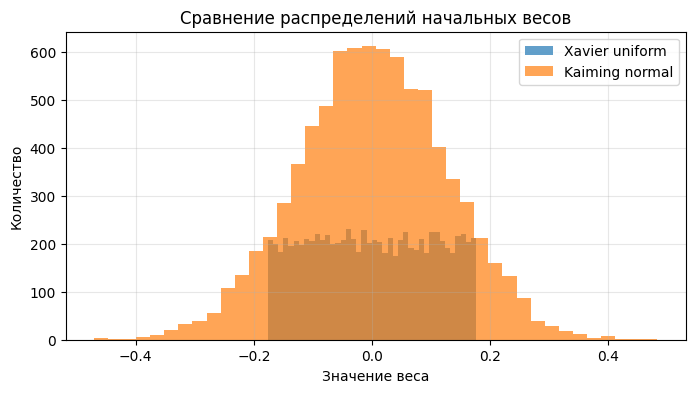

In [85]:
layer_xavier = nn.Linear(128, 64)
layer_kaiming = nn.Linear(128, 64)

nn.init.xavier_uniform_(layer_xavier.weight)
nn.init.kaiming_normal_(layer_kaiming.weight, nonlinearity="relu")

plt.figure(figsize=(8, 4))
plt.hist(layer_xavier.weight.detach().flatten().numpy(), bins=40, alpha=0.7, label="Xavier uniform")
plt.hist(layer_kaiming.weight.detach().flatten().numpy(), bins=40, alpha=0.7, label="Kaiming normal")
plt.title("Сравнение распределений начальных весов")
plt.xlabel("Значение веса")
plt.ylabel("Количество")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
